# CITRUS — sgACC Network Functional Connectivity

**Goal:** Evaluate sgACC (BA25) resting-state connectivity changes before and after TUS,  
comparing exp-focused vs con-defocused sessions across 4 timepoints.

**Pipeline (nilearn-based, workshop style):**
1. Load BOLD + confounds (MEPrep / proc-pmeica output)
2. Seed-based FC: sgACC → whole brain (Fisher z maps)
3. Network ROI extraction (connectivity matrix)
4. Temporal visualisation across timepoints
5. Radar chart — sgACC network profile
6. Group-level summary

---
> **To use on your own data:** Only change the paths in the `CONFIGURATION` cell below. Everything else runs automatically.

## ── CONFIGURATION — change only this cell ──

In [125]:
from pathlib import Path

# ─────────────────────────────────────────────────────────────
# CHANGE THESE PATHS TO MATCH YOUR DATA
# ─────────────────────────────────────────────────────────────
MEPREP_ROOT  = Path("/Volumes/Extreme SSD/THESIS-MSC/MEPrep output")
CITRUS_INPUT = Path("/Users/hoaithunguyen/Projects/Master-thesis/CITRUS/data/input")
OUT_DIR      = Path("/Users/hoaithunguyen/Projects/Master-thesis/CITRUS/derivatives/rs_fmri")
FSL_BIN      = Path("/Users/hoaithunguyen/fsl/bin")

# Subjects to process
SUBJECTS   = ["sub-05"]   # add others when MEPrep is done
SESSIONS   = ["ses-exp", "ses-con"]
TIMEPOINTS = ["preTUS15", "postTUS15", "postTUS30", "postTUS45"]

# Acquisition parameters
TR          = 1.50          # seconds
SMOOTH_FWHM = 6.0           # mm
BANDPASS    = (0.01, 0.10)  # Hz

# ─────────────────────────────────────────────────────────────
# Harvard-Oxford network nodes (L+R averaged for lateralised)
# ─────────────────────────────────────────────────────────────
# Midline cortical — single bilateral node (cortical atlas label index)
MIDLINE_NODES = {
    "Frontal_Medial":  25,   # Frontal Medial Cortex
    "Paracingulate":   28,   # Paracingulate Gyrus
    "ACC":             29,   # Cingulate Gyrus, anterior division
    "PCC":             30,   # Cingulate Gyrus, posterior division
    "Precuneus":       31,   # Precuneous Cortex
}

# Lateralised — Left index, Right index (subcortical atlas)
LATERAL_NODES = {
    "Insula":      (2,  2),    # Insular Cortex (cortical)
    "Hippocampus": (9,  19),   # Left/Right Hippocampus (subcortical)
    "Amygdala":    (10, 20),   # Left/Right Amygdala (subcortical)
    "Thalamus":    (4,  15),   # Left/Right Thalamus (subcortical)
    "Accumbens":   (11, 21),   # Left/Right Accumbens (subcortical)
}


# ─────────────────────────────────────────────────────────────
# Derived — do not change below
BOLD_PROC  = "pmeica"
BOLD_SPACE = "MNI152NLin2009cAsym"
NET_ROIS   = list(MIDLINE_NODES.keys()) + list(LATERAL_NODES.keys())

SES_COLORS = {"ses-exp": "#e05c5c", "ses-con": "#5c7de0"}
SES_LABELS = {"ses-exp": "Experimental (focused)", "ses-con": "Control (defocused)"}
TP_LABELS  = {"preTUS15": "Pre\n(−15 min)", "postTUS15": "Post\n(+15 min)",
              "postTUS30": "Post\n(+30 min)", "postTUS45": "Post\n(+45 min)"}

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Config ready.")
print("  SSD mounted:      ", MEPREP_ROOT.exists())
print("  CITRUS input dir: ", CITRUS_INPUT.exists())
print("  FSL flirt:        ", (FSL_BIN / "flirt").exists())

Config ready.
  SSD mounted:       True
  CITRUS input dir:  True
  FSL flirt:         True


## 0 — Imports

In [126]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from nilearn import image, plotting
from nilearn.maskers import NiftiSpheresMasker, NiftiMasker

print("All imports OK")

All imports OK


## 1 — Helper: locate files

In [152]:
import subprocess
import os
import numpy as np
import nibabel as nib
from nilearn import image
from pathlib import Path

FSLDIR = FSL_BIN.parent

def _flirt(args):
    """Run flirt with FSL env vars set explicitly."""
    fsl_env = {**os.environ,
               "FSLDIR": str(FSLDIR),
               "FSLOUTPUTTYPE": "NIFTI_GZ",
               "PATH": str(FSL_BIN) + ":" + os.environ.get("PATH", "")}
    return subprocess.run([str(FSL_BIN / "flirt")] + args,
                          capture_output=True, text=True, env=fsl_env)


def register_kplan_to_mni(sub: str):
    """Register kplan T1w -> MNI T1w via flirt. Returns .mat path or None."""
    kplan_t1 = CITRUS_INPUT / sub / f"{sub}_T1w_kplan.nii.gz"
    mni_t1   = MEPREP_ROOT / "ses-intake" / f"{sub}_ses-intake_acq-HCP_space-{BOLD_SPACE}_desc-preproc_T1w.nii.gz"
    out_dir  = OUT_DIR / "seeds" / sub
    out_dir.mkdir(parents=True, exist_ok=True)
    mat_path = out_dir / f"{sub}_kplan_to_MNI.mat"

    if mat_path.exists():
        print(f"  [{sub}] flirt .mat already exists — skipping")
        return mat_path
    if not kplan_t1.exists():
        print(f"  [{sub}] MISSING kplan T1w: {kplan_t1}")
        return None
    if not mni_t1.exists():
        print(f"  [{sub}] MISSING MNI T1w: {mni_t1}")
        return None

    print(f"  [{sub}] Running flirt (kplan T1w -> MNI T1w)...")
    result = _flirt(["-in", str(kplan_t1), "-ref", str(mni_t1),
                     "-omat", str(mat_path), "-dof", "12",
                     "-cost", "corratio", "-interp", "spline"])
    if result.returncode != 0:
        print(f"  [{sub}] flirt FAILED:\n{result.stderr}")
        return None
    print(f"  [{sub}] flirt done -> {mat_path.name}")
    return mat_path


def warp_mask_to_mni(sub: str, hemi: str, mat_path) -> Path | None:
    """Warp one hemisphere sgACC mask to MNI. Returns output mask path or None."""
    mask_kplan = CITRUS_INPUT / sub / f"sgACC_BA25_{hemi}_kplan.nii.gz"
    mni_t1     = MEPREP_ROOT / "ses-intake" / f"{sub}_ses-intake_acq-HCP_space-{BOLD_SPACE}_desc-preproc_T1w.nii.gz"
    out_dir    = OUT_DIR / "seeds" / sub
    out_mask   = out_dir / f"{sub}_sgACC_BA25_{hemi}_MNI.nii.gz"

    if out_mask.exists():
        return out_mask

    if not mask_kplan.exists():
        print(f"  [{sub}] MISSING kplan mask: {mask_kplan}")
        return None
    if not mni_t1.exists():
        print(f"  [{sub}] MISSING MNI T1w (SSD not mounted?): {mni_t1}")
        return None

    result = _flirt(["-in", str(mask_kplan), "-ref", str(mni_t1),
                     "-init", str(mat_path), "-applyxfm",
                     "-interp", "nearestneighbour", "-out", str(out_mask)])
    if result.returncode != 0:
        print(f"  [{sub}] mask warp FAILED:\n{result.stderr}")
        return None
    if not out_mask.exists():
        print(f"  [{sub}] mask warp produced no output:\n{result.stderr}")
        return None
    return out_mask


def make_bilateral_seed_mask(sub: str, mask_L: Path, mask_R: Path) -> Path | None:
    """Combine L+R warped sgACC masks into one bilateral voxel mask."""
    out_dir  = OUT_DIR / "seeds" / sub
    out_path = out_dir / f"{sub}_sgACC_BA25_bilateral_MNI.nii.gz"
    if out_path.exists():
        return out_path
    img_L = nib.load(str(mask_L))
    img_R = nib.load(str(mask_R))
    bilateral = (img_L.get_fdata() + img_R.get_fdata()) > 0.5
    nib.save(nib.Nifti1Image(bilateral.astype(np.float32), img_L.affine), str(out_path))
    return out_path


# ── Run for all subjects ──────────────────────────────────────
SUBJECT_MASKS = {}   # sub -> Path to bilateral sgACC MNI mask

for sub in SUBJECTS:
    mat = register_kplan_to_mni(sub)
    if mat is None:
        continue

    hemi_masks = {}
    for hemi in ["L", "R"]:
        p = warp_mask_to_mni(sub, hemi, mat)
        if p is not None:
            hemi_masks[hemi] = p
            n_vox = int((nib.load(str(p)).get_fdata() > 0.5).sum())
            print(f"  [{sub}] sgACC_{hemi} MNI mask: {n_vox} voxels")

    if "L" in hemi_masks and "R" in hemi_masks:
        bil = make_bilateral_seed_mask(sub, hemi_masks["L"], hemi_masks["R"])
    elif hemi_masks:
        bil = list(hemi_masks.values())[0]
    else:
        print(f"  [{sub}] no masks available — skipping")
        continue

    SUBJECT_MASKS[sub] = bil
    n_vox = int((nib.load(str(bil)).get_fdata() > 0.5).sum())
    print(f"  [{sub}] bilateral seed mask: {n_vox} voxels -> {bil.name}")

print(f"\nSeed masks ready for {len(SUBJECT_MASKS)} subject(s):")
for sub, p in SUBJECT_MASKS.items():
    print(f"  {sub}: {p}")


  [sub-05] flirt .mat already exists — skipping
  [sub-05] sgACC_L MNI mask: 570 voxels
  [sub-05] sgACC_R MNI mask: 812 voxels
  [sub-05] bilateral seed mask: 1382 voxels -> sub-05_sgACC_BA25_bilateral_MNI.nii.gz

Seed masks ready for 1 subject(s):
  sub-05: /Users/hoaithunguyen/Projects/Master-thesis/CITRUS/derivatives/rs_fmri/seeds/sub-05/sub-05_sgACC_BA25_bilateral_MNI.nii.gz


## 1b — Per-subject sgACC seed mask in MNI space
Warp each subject's kplan sgACC masks (L + R hemispheres) to MNI space using FSL flirt.
Merge L + R into one bilateral voxel mask — all sgACC voxels from both hemispheres.
This mask is used directly as the seed: mean BOLD signal across all its voxels = the sgACC time series.

In [153]:
def find_run(sub, ses, acq):
    """Return (bold_path, mask_path, confounds_path) or (None,None,None)."""
    func_dir = MEPREP_ROOT / ses / "func"
    stem = f"{sub}_{ses}_task-rest_acq-{acq}_proc-{BOLD_PROC}"
    bold = func_dir / f"{stem}_space-{BOLD_SPACE}_desc-preproc_bold.nii.gz"
    mask = func_dir / f"{stem}_space-{BOLD_SPACE}_desc-brain_mask.nii.gz"
    conf = func_dir / f"{stem}_desc-confounds_timeseries.tsv"
    if bold.exists() and mask.exists() and conf.exists():
        return bold, mask, conf
    print(f"  MISSING: {sub} | {ses} | {acq}")
    return None, None, None


def get_confounds(conf_path):
    """Build confound matrix: 24 HMP + 5 aCompCor + cosine drift + motion outliers."""
    df = pd.read_csv(conf_path, sep="\t")
    hmp = ["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z"]
    hmp24 = hmp + [f"{c}_derivative1" for c in hmp] + \
                  [f"{c}_power2"       for c in hmp] + \
                  [f"{c}_derivative1_power2" for c in hmp]
    acomp  = [f"a_comp_cor_{i:02d}" for i in range(5)]
    cosine = [c for c in df.columns if c.startswith("cosine")]
    outliers = [c for c in df.columns if c.startswith("motion_outlier")]
    cols = [c for c in hmp24 + acomp + cosine + outliers if c in df.columns]
    return df[cols].fillna(0).values


# Quick check: can we find sub-05 data?
bold, mask, conf = find_run("sub-05", "ses-exp", "preTUS15")
print("Found:", bold.name if bold else "NOT FOUND")

Found: sub-05_ses-exp_task-rest_acq-preTUS15_proc-pmeica_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


## 2 — Seed-based FC (nilearn style)

Following the [nilearn seed-to-voxel tutorial](https://nilearn.github.io/stable/auto_examples/03_connectivity/plot_seed_to_voxel_correlation.html).  
Confound regression + bandpass happens **inside** the masker — no separate preprocessing step needed.

In [129]:
def compute_seed_fc(bold_path, mask_path, conf_path, seed_coord, seed_radius=6.0):
    """
    Seed-based FC map (Fisher z) using nilearn maskers.
    Confound regression + bandpass done inside masker (workshop style).
    Returns: z_img (NIfTI), seed_ts (1D array)
    """
    confounds = get_confounds(conf_path)

    # ── Step A: extract seed time series ──────────────────────
    seed_masker = NiftiSpheresMasker(
        seeds=[seed_coord],
        radius=seed_radius,
        mask_img=str(mask_path),
        detrend=True,
        standardize="zscore_sample",
        low_pass=BANDPASS[1],
        high_pass=BANDPASS[0],
        t_r=TR,
        verbose=0,
    )
    seed_ts = seed_masker.fit_transform(str(bold_path), confounds=confounds).squeeze()

    # ── Step B: extract whole-brain time series ────────────────
    brain_masker = NiftiMasker(
        mask_img=str(mask_path),
        smoothing_fwhm=SMOOTH_FWHM,
        detrend=True,
        standardize="zscore_sample",
        low_pass=BANDPASS[1],
        high_pass=BANDPASS[0],
        t_r=TR,
        verbose=0,
    )
    brain_ts = brain_masker.fit_transform(str(bold_path), confounds=confounds)

    # ── Step C: correlation + Fisher z ────────────────────────
    r = np.dot(brain_ts.T, seed_ts) / (seed_ts.shape[0] - 1)
    r = np.clip(r, -0.999, 0.999)
    z = np.arctanh(r)

    z_img = brain_masker.inverse_transform(z)
    return z_img, seed_ts


print("compute_seed_fc() defined")

compute_seed_fc() defined


### 2a — Run for all subjects × sessions × timepoints × seeds

In [130]:
fc_results = {}   # key: (sub, ses, acq, seed_name) → z_img

for sub in SUBJECTS:
    for ses in SESSIONS:
        for acq in TIMEPOINTS:
            bold, mask, conf = find_run(sub, ses, acq)
            if bold is None:
                continue
            for seed_name, seed_coord in SEEDS.items():
                key = (sub, ses, acq, seed_name)
                # Check cache on disk
                out_path = OUT_DIR / "seed_fc" / sub / ses / \
                           f"{sub}_{ses}_acq-{acq}_seed-{seed_name}_fc.nii.gz"
                if out_path.exists():
                    fc_results[key] = nib.load(str(out_path))
                    print(f"  Loaded cache: {sub} | {ses} | {acq} | {seed_name}")
                    continue

                print(f"  Computing: {sub} | {ses} | {acq} | {seed_name} ...", end=" ")
                z_img, _ = compute_seed_fc(bold, mask, conf, seed_coord)
                out_path.parent.mkdir(parents=True, exist_ok=True)
                z_img.to_filename(str(out_path))
                fc_results[key] = z_img
                print("done")

print(f"\nTotal FC maps computed: {len(fc_results)}")

  Loaded cache: sub-05 | ses-exp | preTUS15 | sgACC_L
  Loaded cache: sub-05 | ses-exp | preTUS15 | sgACC_R
  Loaded cache: sub-05 | ses-exp | postTUS15 | sgACC_L
  Loaded cache: sub-05 | ses-exp | postTUS15 | sgACC_R
  Loaded cache: sub-05 | ses-exp | postTUS30 | sgACC_L
  Loaded cache: sub-05 | ses-exp | postTUS30 | sgACC_R
  Loaded cache: sub-05 | ses-exp | postTUS45 | sgACC_L
  Loaded cache: sub-05 | ses-exp | postTUS45 | sgACC_R
  Loaded cache: sub-05 | ses-con | preTUS15 | sgACC_L
  Loaded cache: sub-05 | ses-con | preTUS15 | sgACC_R
  Loaded cache: sub-05 | ses-con | postTUS15 | sgACC_L
  Loaded cache: sub-05 | ses-con | postTUS15 | sgACC_R
  Loaded cache: sub-05 | ses-con | postTUS30 | sgACC_L
  Loaded cache: sub-05 | ses-con | postTUS30 | sgACC_R
  Loaded cache: sub-05 | ses-con | postTUS45 | sgACC_L
  Loaded cache: sub-05 | ses-con | postTUS45 | sgACC_R

Total FC maps computed: 16


### 2b — Visualise FC maps (workshop style)

In [142]:
from nilearn import datasets, image
import numpy as np

# ── Build Harvard-Oxford network masks ───────────────────────
print("Loading Harvard-Oxford atlases...")
ho_cort = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_sub  = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-2mm')

cort_img = ho_cort.maps    # 4D probability or maxprob label image
sub_img  = ho_sub.maps

# Use 2mm MNI BOLD as reference grid
bold_ref = MEPREP_ROOT / "ses-exp" / "func" / \
    f"sub-05_ses-exp_task-rest_acq-preTUS15_proc-{BOLD_PROC}_space-{BOLD_SPACE}_desc-preproc_bold.nii.gz"
ref_img = image.index_img(image.load_img(str(bold_ref)), 0)

# Resample atlases to BOLD grid
cort_res = image.resample_to_img(cort_img, ref_img, interpolation="nearest")
sub_res  = image.resample_to_img(sub_img,  ref_img, interpolation="nearest")
cort_data = cort_res.get_fdata()
sub_data  = sub_res.get_fdata()

def make_roi_mask(label_img_data, label_idx, ref_img):
    """Binary mask for a given label index."""
    mask = (label_img_data == label_idx).astype(np.float32)
    return image.new_img_like(ref_img, mask)

def make_bilateral_mask(data, l_idx, r_idx, ref_img):
    """Combine L + R labels into one bilateral mask."""
    mask = ((data == l_idx) | (data == r_idx)).astype(np.float32)
    return image.new_img_like(ref_img, mask)

# ── Build network ROI masks ───────────────────────────────────
NETWORK_MASKS = {}

# Midline cortical nodes (single mask)
for name, idx in MIDLINE_NODES.items():
    NETWORK_MASKS[name] = make_roi_mask(cort_data, idx, ref_img)
    n_vox = int((cort_data == idx).sum())
    print(f"  {name:20s} (cortical label {idx:3d}): {n_vox} voxels")

# Insula — cortical atlas, split by x-coordinate (x<0 = L, x>0 = R), then combine
insula_mask = (cort_data == LATERAL_NODES["Insula"][0]).astype(np.float32)
NETWORK_MASKS["Insula"] = image.new_img_like(ref_img, insula_mask)
print(f"  {'Insula':20s} (cortical, bilateral): {int(insula_mask.sum())} voxels")

# Lateralised subcortical — L+R combined
for name, (l_idx, r_idx) in LATERAL_NODES.items():
    if name == "Insula":
        continue  # already handled above
    NETWORK_MASKS[name] = make_bilateral_mask(sub_data, l_idx, r_idx, ref_img)
    n_vox = int(((sub_data == l_idx) | (sub_data == r_idx)).sum())
    print(f"  {name:20s} (subcortical L{l_idx}+R{r_idx}): {n_vox} voxels")

print(f"\nNetwork has {len(NETWORK_MASKS)} nodes: {list(NETWORK_MASKS.keys())}")


# ── Extract time series and connectivity ──────────────────────
from nilearn.maskers import NiftiMasker, NiftiSpheresMasker

def extract_network_connectivity(bold_path, mask_path, conf_path, seed_coord):
    """
    Returns:
      fc_dict  — {roi_name: Fisher-z FC value} (seed → each network node)
      roi_ts   — (n_TRs, n_network_nodes) array
    """
    confounds = get_confounds(conf_path)

    # Seed time series (subject-specific sgACC coordinate)
    seed_masker = NiftiSpheresMasker(
        seeds=[seed_coord], radius=6.0,
        mask_img=str(mask_path),
        detrend=True, standardize="zscore_sample",
        low_pass=BANDPASS[1], high_pass=BANDPASS[0], t_r=TR, verbose=0,
    )
    seed_ts = seed_masker.fit_transform(str(bold_path), confounds=confounds).squeeze()

    # Each network node time series
    roi_ts_list = []
    for roi_name, roi_mask in NETWORK_MASKS.items():
        node_masker = NiftiMasker(
            mask_img=roi_mask,
            detrend=True, standardize="zscore_sample",
            low_pass=BANDPASS[1], high_pass=BANDPASS[0], t_r=TR, verbose=0,
        )
        node_ts = node_masker.fit_transform(str(bold_path), confounds=confounds)
        # Average across voxels in this ROI
        roi_ts_list.append(node_ts.mean(axis=1))

    roi_ts = np.column_stack(roi_ts_list)   # (n_TRs, n_rois)

    # Seed → each node: Pearson r → Fisher z
    n = seed_ts.shape[0]
    fc_dict = {}
    for i, roi_name in enumerate(NETWORK_MASKS.keys()):
        r = np.dot(seed_ts, roi_ts[:, i]) / (n - 1)
        r = np.clip(r, -0.999, 0.999)
        fc_dict[roi_name] = float(np.arctanh(r))

    return fc_dict, roi_ts


# ── Run for all subjects / sessions / timepoints ──────────────
net_records = []

for sub in SUBJECTS:
    if sub not in SUBJECT_SEEDS:
        print(f"No seed for {sub} — run seed cell first")
        continue
    seed_coord = SUBJECT_SEEDS[sub]

    for ses in SESSIONS:
        for acq in TIMEPOINTS:
            bold, mask, conf = find_run(sub, ses, acq)
            if bold is None:
                continue
            print(f"  Network: {sub} | {ses} | {acq} ...", end=" ")
            fc_dict, _ = extract_network_connectivity(bold, mask, conf, seed_coord)
            for roi_name, fc_z in fc_dict.items():
                net_records.append({"subject": sub, "session": ses,
                                    "timepoint": acq, "roi": roi_name, "fc_z": fc_z})
            print(f"done — seed={seed_coord}")

df_fc = pd.DataFrame(net_records)
print(f"\nFC table: {len(df_fc)} rows")
df_fc.head(10)

Loading Harvard-Oxford atlases...


[fetch_atlas_harvard_oxford] Dataset found in /Users/hoaithunguyen/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Dataset found in /Users/hoaithunguyen/nilearn_data/fsl

  Frontal_Medial       (cortical label  25): 473 voxels
  Paracingulate        (cortical label  28): 1498 voxels
  ACC                  (cortical label  29): 1345 voxels
  PCC                  (cortical label  30): 1235 voxels
  Precuneus            (cortical label  31): 2833 voxels
  Insula               (cortical, bilateral): 1179 voxels
  Hippocampus          (subcortical L9+R19): 696 voxels
  Amygdala             (subcortical L10+R20): 346 voxels
  Thalamus             (subcortical L4+R15): 1344 voxels
  Accumbens            (subcortical L11+R21): 87 voxels

Network has 10 nodes: ['Frontal_Medial', 'Paracingulate', 'ACC', 'PCC', 'Precuneus', 'Insula', 'Hippocampus', 'Amygdala', 'Thalamus', 'Accumbens']
  Network: sub-05 | ses-exp | preTUS15 ... done — seed=(np.float64(-0.3), np.float64(12.7), np.float64(-13.4))
  Network: sub-05 | ses-exp | postTUS15 ... done — seed=(np.float64(-0.3), np.float64(12.7), np.float64(-13.4))
  Network: sub-05 | ses-exp | postTUS30 ... done — seed=(np.f

,subject,session,timepoint,roi,fc_z
0,sub-05,ses-exp,preTUS15,Frontal_Medial,0.277203
1,sub-05,ses-exp,preTUS15,Paracingulate,0.049674
2,sub-05,ses-exp,preTUS15,ACC,0.058579
3,sub-05,ses-exp,preTUS15,PCC,0.235647
4,sub-05,ses-exp,preTUS15,Precuneus,0.089204
5,sub-05,ses-exp,preTUS15,Insula,0.005488
6,sub-05,ses-exp,preTUS15,Hippocampus,0.103411
7,sub-05,ses-exp,preTUS15,Amygdala,-0.051163
8,sub-05,ses-exp,preTUS15,Thalamus,0.033618
9,sub-05,ses-exp,preTUS15,Accumbens,0.102263


## 3 — ROI network connectivity

Extract time series from 12 sgACC network nodes and compute pairwise connectivity matrix.

In [156]:
def extract_network_connectivity(bold_path, mask_path, conf_path, seed_mask=None):
    """
    Compute sgACC seed -> network ROI FC using full voxel masks throughout.

    seed_mask    : Path to bilateral sgACC MNI voxel mask (NiftiMasker)
    NETWORK_MASKS: dict of full Harvard-Oxford atlas voxel masks (NiftiMasker)

    Returns
    -------
    z_mat     : (n_rois, n_rois) pairwise Fisher-z matrix between network ROIs
    roi_ts    : (n_TRs, n_rois) ROI mean time series
    roi_names : list of ROI names
    seed_fc   : {roi_name: Fisher-z} seed->ROI FC, or None if no seed_mask
    """
    confounds = get_confounds(conf_path)
    roi_names = list(NETWORK_MASKS.keys())

    # ── Network ROI time series (full atlas voxel masks) ──────
    roi_ts_list = []
    for roi_mask in NETWORK_MASKS.values():
        masker = NiftiMasker(
            mask_img=roi_mask,
            smoothing_fwhm=SMOOTH_FWHM,
            detrend=True, standardize="zscore_sample",
            low_pass=BANDPASS[1], high_pass=BANDPASS[0], t_r=TR, verbose=0,
        )
        ts = masker.fit_transform(str(bold_path), confounds=confounds)
        roi_ts_list.append(ts.mean(axis=1))

    roi_ts = np.column_stack(roi_ts_list)   # (n_TRs, n_rois)

    # ── Pairwise connectivity matrix ───────────────────────────
    r_mat = np.corrcoef(roi_ts.T)
    np.fill_diagonal(r_mat, 0)
    z_mat = np.arctanh(np.clip(r_mat, -0.999, 0.999))

    # ── Seed -> each network ROI (full voxel mask for seed) ───
    seed_fc = None
    if seed_mask is not None:
        seed_masker = NiftiMasker(
            mask_img=str(seed_mask),
            smoothing_fwhm=SMOOTH_FWHM,
            detrend=True, standardize="zscore_sample",
            low_pass=BANDPASS[1], high_pass=BANDPASS[0], t_r=TR, verbose=0,
        )
        seed_ts = seed_masker.fit_transform(str(bold_path), confounds=confounds).mean(axis=1)
        n = seed_ts.shape[0]
        seed_fc = {}
        for i, roi_name in enumerate(roi_names):
            r = np.dot(seed_ts, roi_ts[:, i]) / (n - 1)
            seed_fc[roi_name] = float(np.arctanh(np.clip(r, -0.999, 0.999)))

    return z_mat, roi_ts, roi_names, seed_fc


# ── Run for all subjects / sessions / timepoints ──────────────
net_records  = []
conn_matrices = {}
ROI_NAMES    = None

for sub in SUBJECTS:
    seed_mask = SUBJECT_MASKS.get(sub)
    if seed_mask is None:
        print(f"  WARNING: no seed mask for {sub} — run cell 1b first")
    for ses in SESSIONS:
        for acq in TIMEPOINTS:
            bold, mask, conf = find_run(sub, ses, acq)
            if bold is None:
                continue
            print(f"  Network: {sub} | {ses} | {acq} ...", end=" ")
            z_mat, roi_ts, roi_names, seed_fc = extract_network_connectivity(
                bold, mask, conf, seed_mask=seed_mask)
            if ROI_NAMES is None:
                ROI_NAMES = roi_names
            conn_matrices[(sub, ses, acq)] = z_mat

            if seed_fc is not None:
                for roi_name, fc_z in seed_fc.items():
                    net_records.append({"subject": sub, "session": ses,
                                        "timepoint": acq, "roi": roi_name, "fc_z": fc_z})
            print("done")

df_fc = pd.DataFrame(net_records)
print(f"\nFC table: {df_fc.shape}  columns: {df_fc.columns.tolist()}")
if df_fc.empty:
    print("WARNING: df_fc is empty — check SUBJECT_MASKS and find_run output above")
else:
    print(df_fc.head())


  Network: sub-05 | ses-exp | preTUS15 ... done
  Network: sub-05 | ses-exp | postTUS15 ... done
  Network: sub-05 | ses-exp | postTUS30 ... done
  Network: sub-05 | ses-exp | postTUS45 ... done
  Network: sub-05 | ses-con | preTUS15 ... done
  Network: sub-05 | ses-con | postTUS15 ... done
  Network: sub-05 | ses-con | postTUS30 ... done
  Network: sub-05 | ses-con | postTUS45 ... done

FC table: (80, 5)  columns: ['subject', 'session', 'timepoint', 'roi', 'fc_z']
  subject  session timepoint             roi      fc_z
0  sub-05  ses-exp  preTUS15  Frontal_Medial  0.290765
1  sub-05  ses-exp  preTUS15   Paracingulate  0.031514
2  sub-05  ses-exp  preTUS15             ACC  0.091787
3  sub-05  ses-exp  preTUS15             PCC  0.308970
4  sub-05  ses-exp  preTUS15       Precuneus  0.152921


### 3a — Visualise connectivity matrix

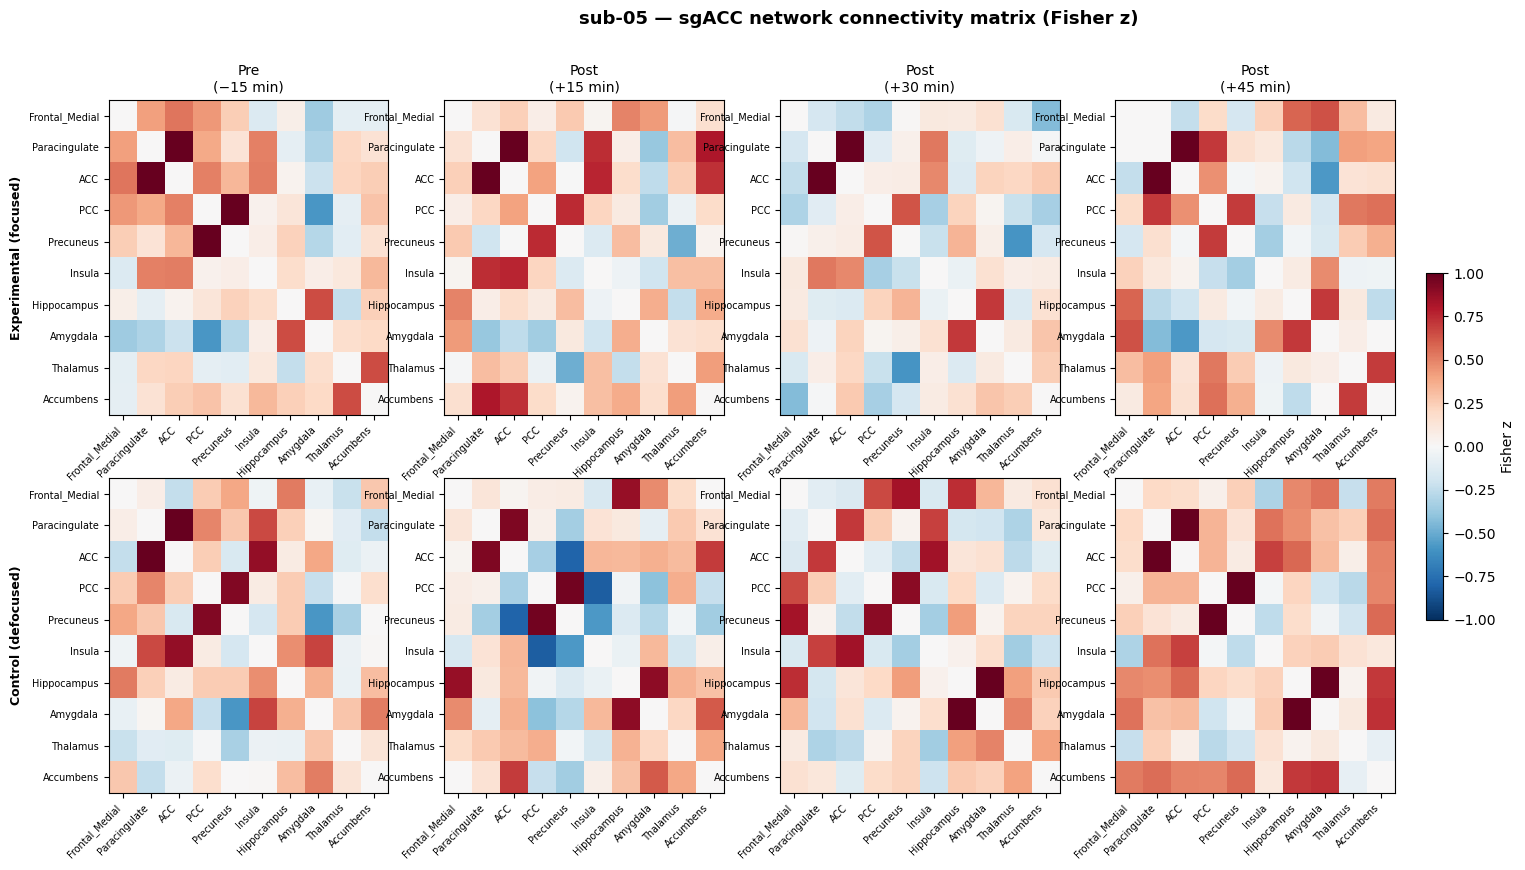

In [157]:
sub = SUBJECTS[0]
n_tp = len(TIMEPOINTS)

fig, axes = plt.subplots(len(SESSIONS), n_tp, figsize=(5*n_tp, 9),
                         facecolor="white")
fig.suptitle(f"{sub} — sgACC network connectivity matrix (Fisher z)",
             fontsize=13, fontweight="bold")

for r, ses in enumerate(SESSIONS):
    for c, acq in enumerate(TIMEPOINTS):
        ax = axes[r, c]
        key = (sub, ses, acq)
        if key not in conn_matrices:
            ax.set_visible(False)
            continue
        im = ax.imshow(conn_matrices[key], cmap="RdBu_r",
                       vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(ROI_NAMES)))
        ax.set_xticklabels(ROI_NAMES, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(len(ROI_NAMES)))
        ax.set_yticklabels(ROI_NAMES, fontsize=7)
        if r == 0:
            ax.set_title(TP_LABELS[acq], fontsize=10)
        if c == 0:
            ax.set_ylabel(SES_LABELS[ses], fontsize=9, fontweight="bold")

fig.colorbar(im, ax=axes, shrink=0.5, label="Fisher z", pad=0.02)
plt.savefig(str(OUT_DIR / f"{sub}_connectivity_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 4 — Temporal line plots: sgACC → each network node

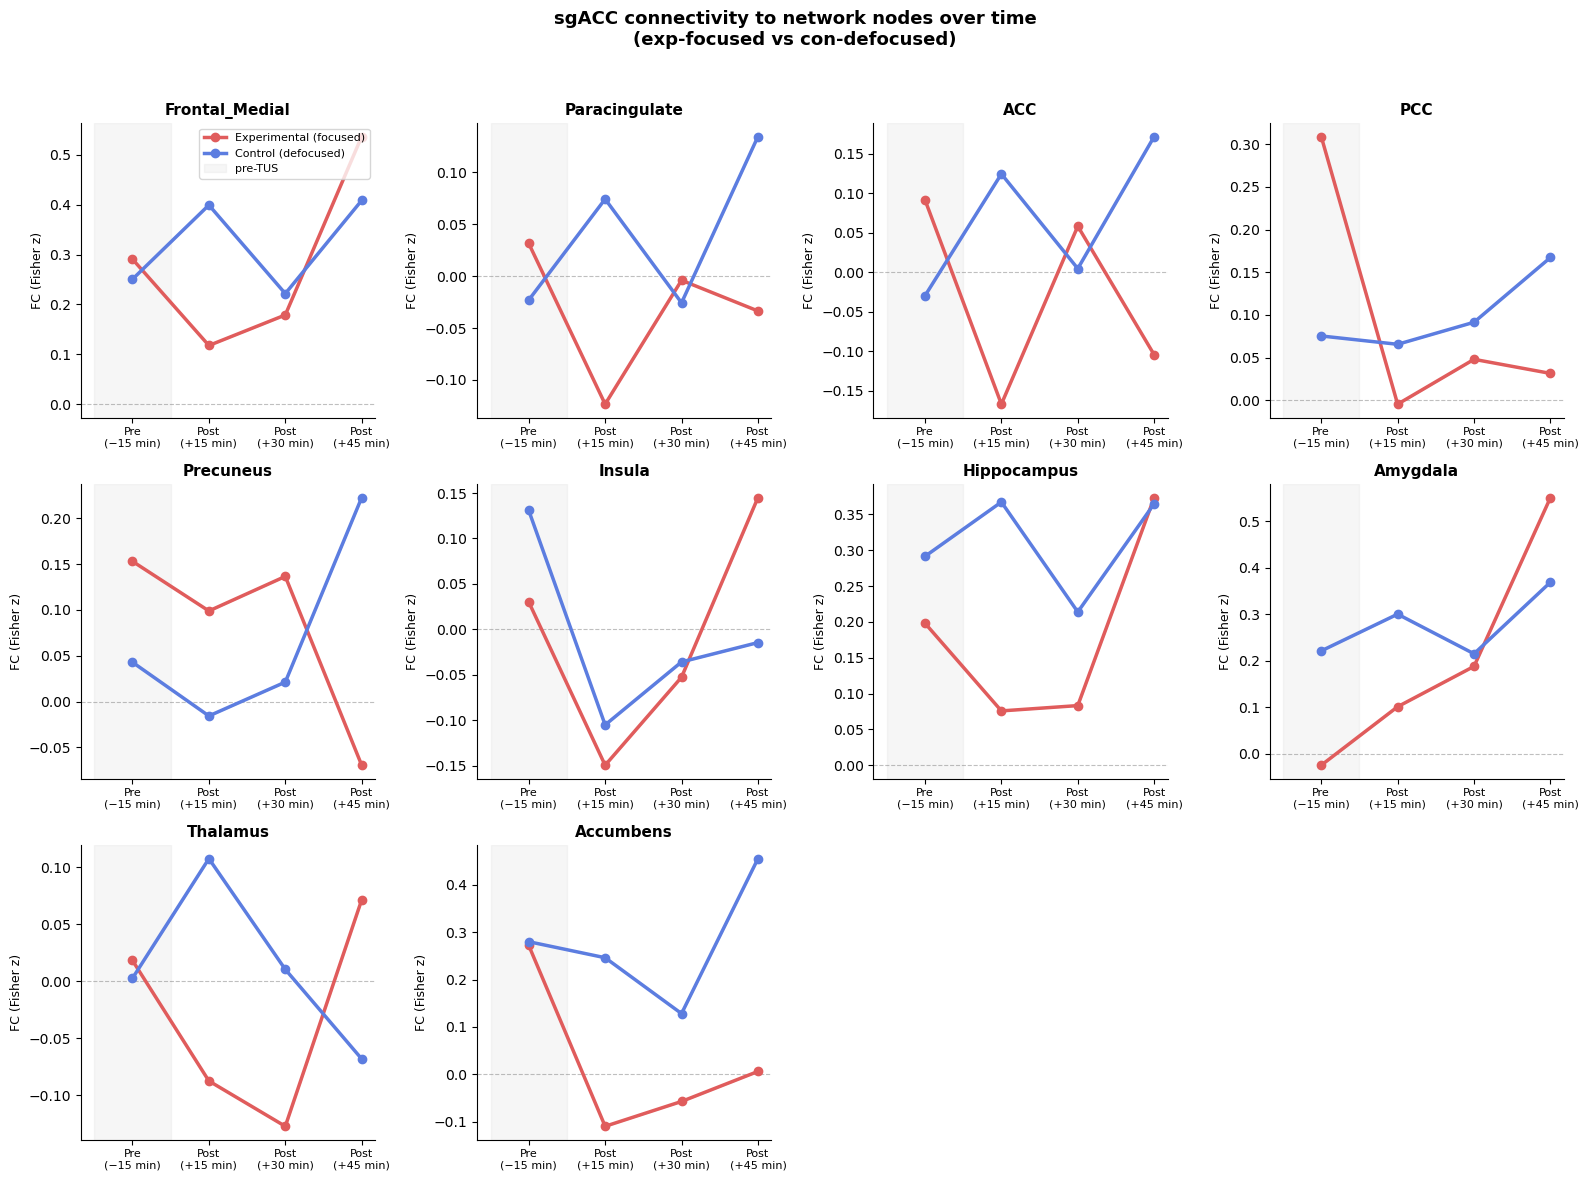

In [158]:
n_rois = len(NET_ROIS)
n_cols = 4
n_rows = int(np.ceil(n_rois / n_cols))
TP_X   = list(range(len(TIMEPOINTS)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows), facecolor="white")
fig.suptitle("sgACC connectivity to network nodes over time\n(exp-focused vs con-defocused)",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax_i, roi in enumerate(NET_ROIS):
    ax = axes[ax_i]
    roi_df = df_fc[df_fc["roi"] == roi]

    for ses in SESSIONS:
        ses_df = roi_df[roi_df["session"] == ses]
        means = [ses_df[ses_df["timepoint"] == tp]["fc_z"].mean() for tp in TIMEPOINTS]
        sems  = [ses_df[ses_df["timepoint"] == tp]["fc_z"].sem()  for tp in TIMEPOINTS]

        color = SES_COLORS[ses]
        ax.plot(TP_X, means, "o-", color=color, lw=2.5, label=SES_LABELS[ses], zorder=3)
        ax.fill_between(TP_X,
                        [m-(s if s==s else 0) for m,s in zip(means,sems)],
                        [m+(s if s==s else 0) for m,s in zip(means,sems)],
                        color=color, alpha=0.15)

    ax.axhline(0, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.axvspan(-0.5, 0.5, color="lightgray", alpha=0.2, label="pre-TUS")
    ax.set_xticks(TP_X)
    ax.set_xticklabels([TP_LABELS[t] for t in TIMEPOINTS], fontsize=8)
    ax.set_title(roi, fontsize=11, fontweight="bold")
    ax.set_ylabel("FC (Fisher z)", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    if ax_i == 0:
        ax.legend(fontsize=8, loc="upper right")

for ax in axes[n_rois:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(str(OUT_DIR / "sgacc_temporal_fc.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5 — Radar chart: sgACC connectivity profile

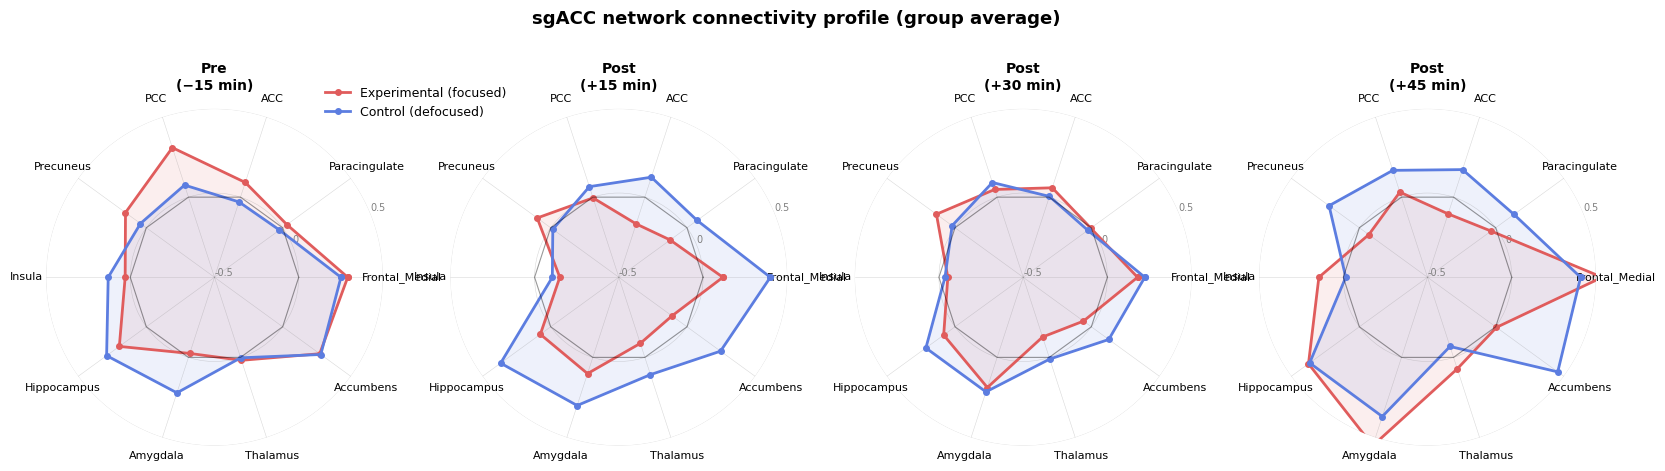

In [159]:
import numpy as np

N     = len(NET_ROIS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

# ── Group-average radar per timepoint ──
fig, axes = plt.subplots(1, len(TIMEPOINTS), figsize=(20, 5),
                         subplot_kw={"projection": "polar"}, facecolor="white")
fig.suptitle("sgACC network connectivity profile (group average)",
             fontsize=13, fontweight="bold", y=1.03)

r_max = df_fc["fc_z"].abs().quantile(0.95) * 1.2 if len(df_fc) > 0 else 1.0

for ax, tp in zip(axes, TIMEPOINTS):
    for ses in SESSIONS:
        vals = [df_fc[(df_fc["session"]==ses) & (df_fc["timepoint"]==tp) &
                      (df_fc["roi"]==roi)]["fc_z"].mean() for roi in NET_ROIS]
        vals_closed = vals + vals[:1]
        color = SES_COLORS[ses]
        ax.plot(angles, vals_closed, "-o", color=color, lw=2,
                markersize=4, label=SES_LABELS[ses])
        ax.fill(angles, vals_closed, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(NET_ROIS, fontsize=8)
    ax.set_ylim(-r_max, r_max)
    ax.set_yticks([-0.5, 0, 0.5])
    ax.set_yticklabels(["-0.5", "0", "0.5"], fontsize=7, color="gray")
    ax.plot(angles, [0]*len(angles), "-", color="black", lw=0.8, alpha=0.4)
    ax.spines["polar"].set_visible(False)
    ax.grid(color="gray", lw=0.4, alpha=0.3)
    ax.set_title(TP_LABELS[tp], fontsize=10, fontweight="bold", pad=14)

axes[0].legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9, frameon=False)
plt.savefig(str(OUT_DIR / "sgacc_radar_group.png"), dpi=150, bbox_inches="tight")
plt.show()

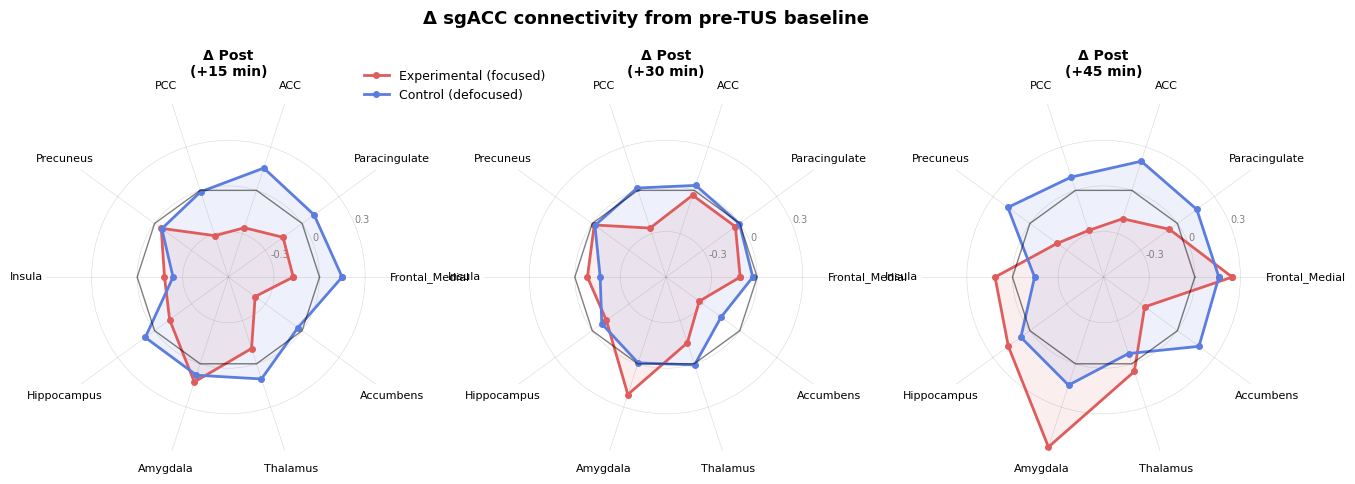

In [160]:
# ── Δ FC radar (post − pre) ──
post_tps = [tp for tp in TIMEPOINTS if tp != "preTUS15"]
fig, axes = plt.subplots(1, len(post_tps), figsize=(16, 5),
                         subplot_kw={"projection": "polar"}, facecolor="white")
fig.suptitle("Δ sgACC connectivity from pre-TUS baseline",
             fontsize=13, fontweight="bold", y=1.03)

for ax, tp in zip(axes, post_tps):
    for ses in SESSIONS:
        pre  = [df_fc[(df_fc["session"]==ses) & (df_fc["timepoint"]=="preTUS15") &
                      (df_fc["roi"]==roi)]["fc_z"].mean() for roi in NET_ROIS]
        post = [df_fc[(df_fc["session"]==ses) & (df_fc["timepoint"]==tp) &
                      (df_fc["roi"]==roi)]["fc_z"].mean() for roi in NET_ROIS]
        delta = [p - pr for p, pr in zip(post, pre)]
        delta_closed = delta + delta[:1]
        color = SES_COLORS[ses]
        ax.plot(angles, delta_closed, "-o", color=color, lw=2,
                markersize=4, label=SES_LABELS[ses])
        ax.fill(angles, delta_closed, color=color, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(NET_ROIS, fontsize=8)
    ax.set_ylim(-0.6, 0.6)
    ax.set_yticks([-0.3, 0, 0.3])
    ax.set_yticklabels(["-0.3", "0", "0.3"], fontsize=7, color="gray")
    ax.plot(angles, [0]*len(angles), "-", color="black", lw=1, alpha=0.5)
    ax.spines["polar"].set_visible(False)
    ax.grid(color="gray", lw=0.4, alpha=0.3)
    ax.set_title(f"Δ {TP_LABELS[tp]}", fontsize=10, fontweight="bold", pad=14)

axes[0].legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9, frameon=False)
plt.savefig(str(OUT_DIR / "sgacc_radar_delta.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6 — Group summary table

In [161]:
if len(df_fc) > 0:
    summary = df_fc.groupby(["session","timepoint","roi"])["fc_z"].agg(
        n="count", mean="mean", sd="std"
    ).reset_index()
    summary["mean_sd"] = summary.apply(
        lambda r: f"{r['mean']:.3f} ± {r['sd']:.3f}" if r['n']>1 else f"{r['mean']:.3f}", axis=1
    )
    pivot = summary.pivot_table(
        index="roi", columns=["session","timepoint"], values="mean"
    ).round(3)
    print(pivot.to_string())
    summary.to_csv(str(OUT_DIR / "sgacc_fc_summary.tsv"), sep="\t", index=False)
    print(f"\nSaved → {OUT_DIR}/sgacc_fc_summary.tsv")
else:
    print("No data yet — run cells above first.")

session          ses-con                                ses-exp                             
timepoint      postTUS15 postTUS30 postTUS45 preTUS15 postTUS15 postTUS30 postTUS45 preTUS15
roi                                                                                         
ACC                0.125     0.005     0.172   -0.030    -0.167     0.058    -0.104    0.092
Accumbens          0.246     0.128     0.455    0.280    -0.110    -0.058     0.006    0.272
Amygdala           0.300     0.215     0.369    0.221     0.101     0.188     0.551   -0.025
Frontal_Medial     0.399     0.222     0.409    0.251     0.118     0.179     0.537    0.291
Hippocampus        0.367     0.214     0.365    0.291     0.076     0.083     0.373    0.198
Insula            -0.105    -0.036    -0.015    0.131    -0.150    -0.053     0.145    0.030
PCC                0.066     0.091     0.167    0.075    -0.005     0.048     0.032    0.309
Paracingulate      0.074    -0.026     0.134   -0.023    -0.123    -0.

---
## Notes

**Current status:**
- Only `sub-05` is preprocessed through MEPrep. Add other subjects to `SUBJECTS` list once their MEPrep output is on the SSD.

**Confound strategy:**
- 24 HMP (6 params + derivatives + squares) + 5 aCompCor + cosine drift + motion outliers
- NO WM/CSF signal regression — MEICA already removes physiological noise
- Bandpass 0.01–0.10 Hz applied inside nilearn masker

**sgACC seed coordinates (MNI152NLin2009cAsym):**
- L: (−6, 22, −8), R: (6, 22, −8) — Fox et al. 2012; Mayberg et al. 2005
- 6 mm sphere radius

**To use on your own data:**
1. Change paths in the `CONFIGURATION` cell
2. Update `SUBJECTS` list
3. Run all cells top to bottom (`Kernel → Restart & Run All`)